### Análisis exploratorio de datos

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



El análisis se lleva a cabo siguiendo los pasos que se detallan a continuación:

1) Definición del problema
2) Recopilación de datos
3) Análisis descriptivo
4) Limpieza de datos
5) Análisis de variables


#### 1) Definición del problema


Para este trabajo se utilizará un dataset proveniente del Sistema de Información Hídrica (SIH), el cual contiene información sobre los Derechos de Uso de Aguas otorgados por la Dirección Nacional de Aguas (DINAGUA) a personas físicas y jurídicas.

El SIH incluye datos asociados a obras de captación de aguas superficiales (tomas y embalses) y subterráneas (pozos). Los datos utilizados provienen una vez que el usuario solicita el derecho en el [Registro de usuarios para trámites de derechos de uso de aguas](https://www.gub.uy/tramites/registro-usuarios-tramites-derechos-uso-aguas).

Dado que el presente análisis se centra en los recursos hídricos subterráneos, se trabajará exclusivamente con los registros correspondientes a pozos.



Posteriormente, se realizará un proceso de exploración, limpieza y preparación de los datos para obtener un conjunto de datos adecuado para el entrenamiento de modelos de Machine Learning. El objetivo es analizar la demora de los trámites de habilitación y las variables que influyen en la duración del trámite de forma de mejorar su gestión.



#### 2) Recopilación de datos


A continuación, se presenta una breve descripción de las variables incluidas en la base de datos, con el objetivo de facilitar la comprensión de la información disponible y su posterior análisis.


| Variable | Descripción |
|-----------|-------------|
| Nro. GEX | Número de expediente |
| Fecha Vencimiento | Vencimiento del derecho de uso de aguas públicas, máximo 10 años, pero depende del uso que se le va a dar al agua. |
| Estado | Estado de la solicitud ante Dinagua: en estudio, pendiente de resolución, registrada. |
| Regional | Oficina de Dinagua encargada del estudio de la solicitud. |
| Departamento | Ubicación de la perforación. |
| Fecha de Resolución | Fecha en la que se emite el derecho de uso de aguas públicas. |
| Caudal | m³/h de extracción de agua autorizados por Dinagua. |
| Volumen | Volumen anual de extracción de agua (Volumen = caudal × hs/día × día/mes × mes/año). |
| Uso | Clasificación general de cuál es el uso que se le va a dar al agua que se extrae. |
| Destino | Subcategoría de uso. Finalidad específica del agua que se extrae. |
| Latitud | Ubicación de la perforación. |
| Longitud | Ubicación de la perforación. |
| Mes Inicio | En qué mes del año se comienza con la extracción de agua. |
| Mes Final | En qué mes del año se finaliza con la extracción de agua. |
| Horas x Año | Cantidad de horas anuales de extracción de agua. |
| Depto.-Padrón | Ubicación de la perforación. |
| Tipo de Obra | En este caso el tipo de obra es perforación. |
| Id Solicitud | Identificador único. |
| Codigo Cuencas de nivel 5 | Cuencas hidrográficas. |
| Sección y localidad catastral | Sección y localidad catastral a la que pertenece el padrón. |
| Cuencas de nivel 3 | Cuencas hidrográficas. |
| Curso a Utilizar | Dato no útil. Relacionado con obras del tipo superficial. |
| Tipo de acuífero | Tipo de acuífero desde donde se obtiene el agua subterránea a extraer. Puede ser fisurado, sedimentario o ambos. |
| Profundidad | Profundidad en metros de la perforación. |
| Diámetro | Diámetro en milímetros de la perforación. |
| Caudal Ensayado | Caudal obtenido en el momento del ensayo de bombeo, medido en m³. |
| Nivel Estático | Profundidad a la que está el agua cuando el pozo no es utilizado por un período mayor a 8 horas, en relación al nivel de superficie. |
| Nivel Dinámico | Profundidad a la que está el agua cuando el pozo está en uso, en relación al nivel de superficie. |
| Caudal Máximo | Dato no útil. |
| Codigo Cuencas de nivel 2 | Cuencas hidrográficas. |
| Producción | Dato no útil. |

#### 2) Importación de dataset y creación del dataframe

In [2]:
df = pd.read_csv("../data/raw/Base_de_datos_Python_GRUPOA.csv", sep=";")

In [3]:
df

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Caudal Máximo,Codigo Cuencas de nivel 2,Accion Solicitud,Tipo Resolución,Producción
0,Proyecto de Aprovechamiento,SGRH-00040200289-635.001,27/Mar/2011,Registrada,SALTO,SALTO,"Rodríguez, Jorge",18/set/2000,27/Mar/2001,NaN,...,55,"0,15","19,7",20,"37,5",NaN,14.0,Nueva,Autorización,7
1,Proyecto de Aprovechamiento,SGRH-00040200324-595.001,19/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,19/Oct/2000,25/Oct/2000,...,53,"0,15",9,25,29,NaN,18.0,Nueva,Autorización,4
2,Proyecto de Aprovechamiento,SGRH-00040200325-596.001,20/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,20/Oct/2000,27/Oct/2000,...,31,"0,15",25,2,5,NaN,18.0,Nueva,Autorización,4
3,Proyecto de Aprovechamiento,SGRH-00040200402-598.001,19/Oct/2010,Registrada,SAN JOSÉ,SAN JOSÉ,"Rodríguez, Jorge",11/Abr/2000,19/Oct/2000,25/Oct/2000,...,55,"0,15",20,28,"32,5",NaN,24.0,Nueva,Autorización,"2,5"
4,Proyecto de Aprovechamiento,SGRH-00040200414-609.001,10/Oct/2010,Registrada,SAN JOSÉ,CANELONES,"Rodríguez, Jorge",14/Abr/2000,10/Oct/2000,18/Oct/2000,...,64,"0,15","6,8","3,9","22,3",NaN,63.0,Nueva,Autorización,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5698,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(5700, 38)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5700 entries, 0 to 5699
Data columns (total 38 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Tipo de Solicitud              5159 non-null   str    
 1   Nro. GEX                       5157 non-null   str    
 2   Fecha Vencimiento              4700 non-null   str    
 3   Estado                         5159 non-null   str    
 4   Regional                       5157 non-null   str    
 5   Departamento                   5157 non-null   str    
 6   Tecnicos                       5142 non-null   str    
 7   Fecha de Solicitud             5158 non-null   str    
 8   Fecha de Resolución            4699 non-null   str    
 9   Fecha de Inscripción           4653 non-null   str    
 10  Caudal                         5113 non-null   str    
 11  Volumen                        5127 non-null   str    
 12  Uso                            5159 non-null   str    
 13 

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Mes Inicio,5123.0,6.718915,5.342711,1.0,1.0,10.0,12.00,12.0
Mes Final,5123.0,9.740582,3.386649,0.0,10.0,11.0,12.00,12.0
Horas x Año,5121.0,3128.130443,1866.384298,1.0,1600.0,2880.0,4320.00,9000.0
Id Solicitud,5159.0,249482.421012,6255.075576,237902.0,244274.5,249362.0,254852.50,261225.0
Codigo Cuencas de nivel 5,5152.0,37711.344332,18888.650444,10105.0,22600.0,27400.0,58171.25,68710.0
Sección y localidad catastral,3387.0,5.623561,13.541791,0.0,2.0,4.0,7.00,746.0
Caudal Máximo,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Codigo Cuencas de nivel 2,5152.0,37.194682,18.909617,10.0,22.0,27.0,58.00,68.0



#### 3) Limpieza de datos

_- Eliminación de duplicados_

In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
5695     True
5696     True
5697     True
5698     True
5699     True
Length: 5700, dtype: bool

In [8]:
df.duplicated().sum()

np.int64(540)

Se identifican 540 filas duplicadas dentro del conjunto de datos que representan aproximadamente el 9,47% del total de observaciones. A continuación se inspeccionan filas duplicadas para confirmarlas y entenderlas previo a eliminarlas.

In [9]:
df[df.duplicated()].head()

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Caudal Máximo,Codigo Cuencas de nivel 2,Accion Solicitud,Tipo Resolución,Producción
5160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5162,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.tail(10)

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Caudal Máximo,Codigo Cuencas de nivel 2,Accion Solicitud,Tipo Resolución,Producción
5690,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5692,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5694,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5698,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5699,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Parecería que las últimas filas del dataset están todas vacías y por lo tanto duplicadas entre si. A continuación se cuentan las filas completamente vacías para confirmar que las filas duplicadas están todas vacías.

In [11]:
df.isnull().all(axis=1).sum()

np.int64(541)


Se verifica la existencia de 541 filas completamente vacías sin información en ninguna de sus variables y, que además, generan 540 registros duplicados dentro del dataset. Por este motivo, se procede a su eliminación.

In [12]:
df = df.dropna(how="all")

In [13]:
print("Filas vacías:", df.isnull().all(axis=1).sum())
print("Duplicados:", df.duplicated().sum())
print("Dimensión:", df.shape)

Filas vacías: 0
Duplicados: 0
Dimensión: (5159, 38)


In [14]:
df

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Caudal Máximo,Codigo Cuencas de nivel 2,Accion Solicitud,Tipo Resolución,Producción
0,Proyecto de Aprovechamiento,SGRH-00040200289-635.001,27/Mar/2011,Registrada,SALTO,SALTO,"Rodríguez, Jorge",18/set/2000,27/Mar/2001,NaN,...,55,"0,15","19,7",20,"37,5",NaN,14.0,Nueva,Autorización,7
1,Proyecto de Aprovechamiento,SGRH-00040200324-595.001,19/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,19/Oct/2000,25/Oct/2000,...,53,"0,15",9,25,29,NaN,18.0,Nueva,Autorización,4
2,Proyecto de Aprovechamiento,SGRH-00040200325-596.001,20/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,20/Oct/2000,27/Oct/2000,...,31,"0,15",25,2,5,NaN,18.0,Nueva,Autorización,4
3,Proyecto de Aprovechamiento,SGRH-00040200402-598.001,19/Oct/2010,Registrada,SAN JOSÉ,SAN JOSÉ,"Rodríguez, Jorge",11/Abr/2000,19/Oct/2000,25/Oct/2000,...,55,"0,15",20,28,"32,5",NaN,24.0,Nueva,Autorización,"2,5"
4,Proyecto de Aprovechamiento,SGRH-00040200414-609.001,10/Oct/2010,Registrada,SAN JOSÉ,CANELONES,"Rodríguez, Jorge",14/Abr/2000,10/Oct/2000,18/Oct/2000,...,64,"0,15","6,8","3,9","22,3",NaN,63.0,Nueva,Autorización,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5154,Proyecto de Aprovechamiento,2026/36001/003138,NaN,En Estudio,DURAZNO,FLORES,MARGARITA MARÍA SIENRA VALLE,23/Mar/2026,NaN,NaN,...,35,150,8,"3,2","4,65",NaN,57.0,Nueva,NaN,0
5155,Proyecto de Aprovechamiento,2026/36001/003236,NaN,En Estudio,FRAY BENTOS,PAYSANDÚ,ALEJANDRO LEONEL SCHIPILOV ZACCHINO,24/Mar/2026,NaN,NaN,...,48,160,7,5,17,NaN,18.0,Nueva,NaN,0
5156,Proyecto de Aprovechamiento,2026/36001/003447,NaN,En Estudio,FRAY BENTOS,COLONIA,Gustavo Norberto Galmarini Silva,6/Abr/2026,NaN,NaN,...,33,150,"2,5",6,25,NaN,23.0,Nueva,NaN,0
5157,Proyecto de Aprovechamiento,2026/36001/003411,NaN,En Estudio,SALTO,SALTO,ALEJANDRO LEONEL SCHIPILOV ZACCHINO,27/Mar/2026,NaN,NaN,...,61,160,7,"6,5",18,NaN,13.0,Renov/Modif,NaN,0


Tras la limpieza, el dataset queda conformado por 5.159 registros y 38 columnas, sin filas completamente vacías ni registros duplicados.

**_- Eliminación de información irrelevante_**

Como parte del proceso de exploración inicial, a continuación, se analiza la cantidad y el porcentaje de valores faltantes en cada columna del dataset. Esta evaluación permite identificar variables con información incompleta y determinar su potencial impacto en análisis posteriores.

In [15]:
faltantes = pd.DataFrame({
        'Cantidad': df.isnull().sum(),
    'Porcentaje': round(df.isnull().sum() / len(df) * 100, 2)})

faltantes.sort_values('Porcentaje', ascending=False)


,Cantidad,Porcentaje
Caudal Máximo,5159,100.00
Producción,3357,65.07
Curso a Utilizar,2584,50.09
Tipo de acuifero,2031,39.37
Sección y localidad catastral,1772,34.35
Fecha de Inscripción,506,9.81
Nivel Dinámico,504,9.77
Tipo Resolución,466,9.03
Fecha de Resolución,460,8.92
Fecha Vencimiento,459,8.90


A continuación se analiza la relevancia analítica y calidad de las variables de la base de datos con el objetivo de eliminar las columnas que no aportan valor al análisis.

La columna "Caudal máximo" presenta un 100% de valores faltantes, por lo que no aporta información para el análisis y se decide su eliminación.

Las columnas "Producción", "Curso a utilizar" y "Tipo de acuífero" tienen un porcentaje de faltantes significativamente superior al resto de las columnas. Además no aportan información relevante para el análisis de la gestión de trámites, por lo que se eliminan del conjunto de datos.

Las columnas "Código Cuencas de nivel 2", "Código Cuencas de nivel 5" y "Cuencas de nivel 3" corresponden a codificaciones geográficas utilizadas para la clasificación de cuencas
hidrográficas. Esta información no resulta relevante para los objetivos del presente análisis, por lo tanto, se decide eliminar dichas variables.

En la columna "Tipo de obra" se identifican registros con valores inconsistentes, concatenaciones erróneas de categorías y denominaciones que no se corresponden con la realidad ya que todos los trámites incluidos en la base de datos corresponden a obras de pozos. La columna no aporta información de utilidad y su contenido presenta inconsistencias. En consecuencia se decide eliminarla del análisis.

La columna "Documento" corresponde a un identificador administrativo del solicitante y no aporta información relevante para el análisis de la gestión de los trámites, por lo que también es eliminada.

Considerando la baja completitud, la poca relevancia para el análisis y los problemas de calidad en las columnas anteriormente mencionadas se decide eliminarlas antes de continuar con el análisis de forma de evitar la incorporación de información irrelevante que pudiera afectar la interpretación de los resultados. Como resultado, se obtiene un conjunto de datos más compacto, reduciendo la complejidad del análisis y concentrando la información en aquellas variables con mayor potencial descriptivo y analítico.

In [16]:
columnas_eliminar = [
    "Caudal Máximo",
    "Producción",
    "Curso a Utilizar",
    "Tipo de acuifero",
    "Codigo Cuencas de nivel 5",
    "Cuencas de nivel 3",
    "Codigo Cuencas de nivel 2",
    "Documento",
    "Tipo de Obra"
]

df = df.drop(columns=columnas_eliminar)

In [17]:
df.shape

(5159, 29)

Tras la eliminación de las columnas el conjunto de datos queda conformado por 5.159 registros y 29 columnas

_- Adecuación del formato de datos_

Durante el análisis inicial de la estructura del dataset, mediante la función df.info(), se identifica que varias variables tienen tipo de dato string (str). Sin embargo, de acuerdo a la definición de las variables y la inspección de los datos, se observa que algunas de ellas corresponden a fechas y otras representan magnitudes numéricas.

Esta situación puede limitar la realización de análisis estadísticos, cálculos y visualizaciones, ya que los tipos de datos no reflejan la naturaleza real de la información almacenada. Por este motivo, se procede a revisar el formato de dichas variables y a convertirlas al tipo de dato más adecuado, con el objetivo de garantizar la consistencia y calidad del conjunto de datos.

a) Adecuación de fechas

Para convertir correctamente las variables de fecha, se realiza una inspección de los formatos presentes en las columnas de fecha.

In [18]:
columnas_fecha = [
    'Fecha de Solicitud',
    'Fecha de Resolución',
    'Fecha de Inscripción',
    'Fecha Vencimiento'
]

In [19]:
for col in columnas_fecha:
    meses = (
        df[col]
        .dropna()
        .str.extract(r'/([A-Za-z]+)/')[0]
        .dropna()
        .unique()
    )

    print(f"\n{col}")
    print(meses)


Fecha de Solicitud
<ArrowStringArray>
['set', 'Mar', 'Abr', 'May', 'Jul', 'Nov', 'Dic', 'Ene', 'Jun', 'Ago', 'Oct',
 'Feb']
Length: 12, dtype: str

Fecha de Resolución
<ArrowStringArray>
['Mar', 'Oct', 'set', 'Dic', 'Jun', 'Abr', 'Jul', 'Nov', 'Ene', 'Ago', 'Feb',
 'May']
Length: 12, dtype: str

Fecha de Inscripción
<ArrowStringArray>
['Oct', 'set', 'Nov', 'Abr', 'Dic', 'Jun', 'Jul', 'Ene', 'Mar', 'Feb', 'Ago',
 'May']
Length: 12, dtype: str

Fecha Vencimiento
<ArrowStringArray>
['Mar', 'Oct', 'set', 'Jun', 'Dic', 'Abr', 'Jul', 'Nov', 'May', 'Ene', 'Feb',
 'Ago', 'Apr', 'Sep', 'Aug']
Length: 15, dtype: str


Se identifica que la mayoría de las fechas utilizan abreviaturas en español (Ene, Abr, Ago, Dic). Sin embargo, se detectaron algunos registros aislados con abreviaturas en inglés, tales como Apr, Aug y Sep.

Dado que la coexistencia de diferentes nomenclaturas puede generar inconsistencias durante el proceso de conversión, se estandarizan las abreviaturas de los meses antes de transformar las variables al formato fecha.

In [20]:
meses = {
    'Ene': 'Jan',
    'Feb': 'Feb',
    'Mar': 'Mar',
    'Abr': 'Apr',
    'May': 'May',
    'Jun': 'Jun',
    'Jul': 'Jul',
    'Ago': 'Aug',
    'set': 'Sep',
    'Oct': 'Oct',
    'Nov': 'Nov',
    'Dic': 'Dec'
}

columnas_fecha = [
    'Fecha de Solicitud',
    'Fecha de Resolución',
    'Fecha de Inscripción',
    'Fecha Vencimiento'
]

for col in columnas_fecha:
    for esp, eng in meses.items():
        df[col] = df[col].str.replace(esp, eng, regex=False)

In [21]:
for col in columnas_fecha:
    df[col] = pd.to_datetime(
        df[col],
        format='%d/%b/%Y',
        errors='coerce'
    )

In [22]:
df[columnas_fecha].dtypes

Fecha de Solicitud      datetime64[us]
Fecha de Resolución     datetime64[us]
Fecha de Inscripción    datetime64[us]
Fecha Vencimiento       datetime64[us]
dtype: object

In [23]:
df[columnas_fecha].head()

,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,Fecha Vencimiento
0,2000-09-18,2001-03-27,NaT,2011-03-27
1,2000-03-10,2000-10-19,2000-10-25,2010-10-19
2,2000-03-10,2000-10-20,2000-10-27,2010-10-20
3,2000-04-11,2000-10-19,2000-10-25,2010-10-19
4,2000-04-14,2000-10-10,2000-10-18,2010-10-10


Luego de estandarizadar las abreviaturas de los meses, se procedió a convertir las variables de fecha al tipo de dato datetime. Esta transformación permite que las fechas sean interpretadas correctamente en la realización de análisis temporales y la generación de visualizaciones cronológicas. Posteriormente, se verificó que las cuatro variables fueran almacenadas correctamente con formato fecha.

b) Adecuación de magnitudes numéricas

Una vez convertidas las variables temporales, se procede a revisar las variables que, de acuerdo con su definición, representan magnitudes numéricas pero que tienen formato texto. Se consideran para esta adecuación de formato las variables cuantitativas sobre las que resulta posible realizar operaciones matemáticas y análisis estadísticos.

Por lo tanto, se consideran para su transformación las variables Caudal, Volumen, Latitud, Longitud, Profundidad, Diámetro, Caudal Ensayado, Nivel Estático y Nivel Dinámico. Los códigos identificadores se mantienen en su formato original, dado que representan categorías o identificadores y no magnitudes numéricas susceptibles de análisis estadístico.

Previo a la conversión, se inspecciona el formato de los registros con el objetivo de identificar posibles inconsistencias, como el uso de distintos separadores decimales o la presencia de caracteres no numéricos, que puedan afectar el proceso de transformación.

In [24]:
columnas_numericas = [
    'Caudal',
    'Volumen',
    'Latitud',
    'Longitud',
    'profundidad',
    'Diámetro',
    'Caudal Ensayado',
    'Nivel Estático',
    'Nivel Dinámico'
]

for col in columnas_numericas:
    print(f"\n--- {col} ---")
    print(df[col].dropna().unique()[:10])


--- Caudal ---
<ArrowStringArray>
['19,7', '9', '25', '20', '6,8', '3', '8', '18', '6', '12,8']
Length: 10, dtype: str

--- Volumen ---
<ArrowStringArray>
['35460', '16200', '16000',  '8000',  '7000',  '3500', '10800', '22500',
  '7500', '14000']
Length: 10, dtype: str

--- Latitud ---
<ArrowStringArray>
['-31,31716746', '-32,34177153', '-32,36978549', '-34,68004373',
  '-34,5045261', '-34,52060124',  '-34,7569185',  '-32,2973834',
 '-32,96808761', '-32,25813999']
Length: 10, dtype: str

--- Longitud ---
<ArrowStringArray>
['-57,95376019', '-58,08282352', '-57,87001899', '-56,73112873',
 '-56,30396653', '-56,22510334', '-56,30549516', '-57,80362401',
  '-58,0426651', '-58,02078585']
Length: 10, dtype: str

--- profundidad ---
<ArrowStringArray>
['55', '53', '31', '64', '50', '36', '58', '79', '134', '60']
Length: 10, dtype: str

--- Diámetro ---
<ArrowStringArray>
['0,15', '0,2', '0,14', '0,22', '0,11', '0,1', '0,24', '203', '0,4', '150']
Length: 10, dtype: str

--- Caudal Ensayado --

Como primera aproximación, se inspeccionan los 10 primeros valores únicos de las variables identificadas como potencialmente numéricas con el objetivo de comprender su formato de almacenamiento. Esta revisión permite observar preliminarmente que los datos se encuentran representados como texto y que, en aquellos casos donde existen valores decimales, se utiliza la coma como separador decimal.

Dado que esta inspección se realiza sobre una muestra de valores muy reducida, posteriormente se efectua una validación de la totalidad de los registros para verificar la existencia de caracteres incompatibles con una representación numérica y detectar posibles inconsistencias que requiran tratamiento previo a la conversión de los datos.

In [25]:
for col in columnas_numericas:
    invalidos = df[
        ~df[col].fillna("").str.match(r"^-?\d+[,.]?\d*$")
    ][col].dropna().unique()

    print(f"\n{col}")
    print(invalidos[:10])


Caudal
<ArrowStringArray>
[]
Length: 0, dtype: str

Volumen
<ArrowStringArray>
[]
Length: 0, dtype: str

Latitud
<ArrowStringArray>
['#¡NUM!']
Length: 1, dtype: str

Longitud
<ArrowStringArray>
[]
Length: 0, dtype: str

profundidad
<ArrowStringArray>
[]
Length: 0, dtype: str

Diámetro
<ArrowStringArray>
[]
Length: 0, dtype: str

Caudal Ensayado
<ArrowStringArray>
[]
Length: 0, dtype: str

Nivel Estático
<ArrowStringArray>
[]
Length: 0, dtype: str

Nivel Dinámico
<ArrowStringArray>
[]
Length: 0, dtype: str


In [26]:
(df["Latitud"] == "#¡NUM!").sum()

np.int64(1)

In [27]:
df[df["Latitud"] == "#¡NUM!"]

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,Depto.-Padrón,Id Solicitud,Sección y localidad catastral,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Accion Solicitud,Tipo Resolución
4772,Proyecto de Aprovechamiento,2025/36001/018383,NaT,Pendiente de Resolución,NaN,NaN,Viviana Leticia González Molina,2025-11-17,NaT,NaT,...,FLORIDA-10834,260740.0,NaN,45,160,"2,9","-2,54","-8,09",Nueva,NaN


Se realiza una verificación sobre la totalidad de los registros para detectar valores incompatibles con una representación numérica. Para esto, se verifica que los valores esten compuestos exclusivamente por caracteres válidos para la representación de números, considerando tanto números enteros como decimales y admitiendo el uso de coma o punto como separador decimal. Para cada columna se identifican los primeros 10 valores que no cumplen con dicho criterio.
Solo se detecta un valor inconsistente en la columna Latitud, correspondiente al registro #¡NUM!, el cual representa un error de origen en los datos. No se identifican otras inconsistencias de formato en las variables analizadas, por lo que se procede a reemplazar dicho valor por un valor nulo y luego a realizar la conversión de las variables al formato numérico correspondiente

In [28]:
df["Latitud"] = df["Latitud"].replace("#¡NUM!", np.nan)

In [29]:
for col in columnas_numericas:
    df[col] = pd.to_numeric(
        df[col].str.replace(",", ".", regex=False),
        errors="coerce"
    )

In [30]:
df[columnas_numericas].dtypes

Caudal             float64
Volumen            float64
Latitud            float64
Longitud           float64
profundidad        float64
Diámetro           float64
Caudal Ensayado    float64
Nivel Estático     float64
Nivel Dinámico     float64
dtype: object

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5159 entries, 0 to 5158
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Tipo de Solicitud              5159 non-null   str           
 1   Nro. GEX                       5157 non-null   str           
 2   Fecha Vencimiento              4685 non-null   datetime64[us]
 3   Estado                         5159 non-null   str           
 4   Regional                       5157 non-null   str           
 5   Departamento                   5157 non-null   str           
 6   Tecnicos                       5142 non-null   str           
 7   Fecha de Solicitud             5158 non-null   datetime64[us]
 8   Fecha de Resolución            4699 non-null   datetime64[us]
 9   Fecha de Inscripción           4653 non-null   datetime64[us]
 10  Caudal                         5113 non-null   float64       
 11  Volumen                     

In [32]:
df

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,Depto.-Padrón,Id Solicitud,Sección y localidad catastral,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Accion Solicitud,Tipo Resolución
0,Proyecto de Aprovechamiento,SGRH-00040200289-635.001,2011-03-27,Registrada,SALTO,SALTO,"Rodríguez, Jorge",2000-09-18,2001-03-27,NaT,...,SALTO-4739,237902.0,2.0,55.0,0.15,19.7,20.0,37.50,Nueva,Autorización
1,Proyecto de Aprovechamiento,SGRH-00040200324-595.001,2010-10-19,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",2000-03-10,2000-10-19,2000-10-25,...,PAYSANDÚ-5331,237906.0,2.0,53.0,0.15,9.0,25.0,29.00,Nueva,Autorización
2,Proyecto de Aprovechamiento,SGRH-00040200325-596.001,2010-10-20,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",2000-03-10,2000-10-20,2000-10-27,...,PAYSANDÚ-2048,237907.0,2.0,31.0,0.15,25.0,2.0,5.00,Nueva,Autorización
3,Proyecto de Aprovechamiento,SGRH-00040200402-598.001,2010-10-19,Registrada,SAN JOSÉ,SAN JOSÉ,"Rodríguez, Jorge",2000-04-11,2000-10-19,2000-10-25,...,SAN JOSÉ-14232,237914.0,6.0,55.0,0.15,20.0,28.0,32.50,Nueva,Autorización
4,Proyecto de Aprovechamiento,SGRH-00040200414-609.001,2010-10-10,Registrada,SAN JOSÉ,CANELONES,"Rodríguez, Jorge",2000-04-14,2000-10-10,2000-10-18,...,CANELONES-19,237926.0,1.0,64.0,0.15,6.8,3.9,22.30,Nueva,Autorización
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5154,Proyecto de Aprovechamiento,2026/36001/003138,NaT,En Estudio,DURAZNO,FLORES,MARGARITA MARÍA SIENRA VALLE,2026-03-23,NaT,NaT,...,FLORES-5177,261209.0,NaN,35.0,150.00,8.0,3.2,4.65,Nueva,NaN
5155,Proyecto de Aprovechamiento,2026/36001/003236,NaT,En Estudio,FRAY BENTOS,PAYSANDÚ,ALEJANDRO LEONEL SCHIPILOV ZACCHINO,2026-03-24,NaT,NaT,...,PAYSANDÚ-13104,261214.0,NaN,48.0,160.00,7.0,5.0,17.00,Nueva,NaN
5156,Proyecto de Aprovechamiento,2026/36001/003447,NaT,En Estudio,FRAY BENTOS,COLONIA,Gustavo Norberto Galmarini Silva,2026-04-06,NaT,NaT,...,COLONIA-18671,261216.0,NaN,33.0,150.00,2.5,6.0,25.00,Nueva,NaN
5157,Proyecto de Aprovechamiento,2026/36001/003411,NaT,En Estudio,SALTO,SALTO,ALEJANDRO LEONEL SCHIPILOV ZACCHINO,2026-03-27,NaT,NaT,...,SALTO-13846,261224.0,NaN,61.0,160.00,7.0,6.5,18.00,Renov/Modif,NaN


c) Adecuación de variables categóricas

Se realiza una revisión de las variables categóricas con el objetivo de identificar posibles inconsistencias en la codificación de las categorías. En particular, se analizan las columnas "Acción Solicitud" y "Tipo Resolución", ya que durante la inspección preliminar de sus datos se observan categorías que sugieren concatenaciones involuntarias de texto.

Para verificar esto, se analizan las categorías presentes en ambas variables y sus respectivas frecuencias con el fin de identificar registros que pudieran corresponder a repeticiones de una misma categoría o errores de codificación.

In [33]:
df["Accion Solicitud"].value_counts(dropna=False)

Accion Solicitud
Nueva                                           4474
Renov/Modif                                      569
NuevaNueva                                        48
NuevaNuevaNueva                                   22
Renov/ModifRenov/Modif                            16
Cesión                                            11
NuevaNuevaNuevaNueva                               7
NuevaNuevaNuevaNuevaNueva                          4
NuevaNuevaNuevaNuevaNuevaNueva                     3
NuevaNuevaNuevaNuevaNuevaNuevaNueva                2
NuevaNuevaNuevaNuevaNuevaNuevaNuevaNueva           1
Renov/ModifRenov/ModifRenov/Modif                  1
Renov/ModifRenov/ModifRenov/ModifRenov/Modif       1
Name: count, dtype: int64

In [35]:
df["Tipo Resolución"].value_counts(dropna=False)

Tipo Resolución
Permiso de uso                                                                                                      4145
NaN                                                                                                                  466
Autorización                                                                                                         414
Permiso de usoPermiso de uso                                                                                          49
Revocación                                                                                                            30
Sin Resolución                                                                                                        25
Permiso de usoPermiso de usoPermiso de uso                                                                            15
Permiso de usoPermiso de usoPermiso de usoPermiso de uso                                                               5
Renovación      

Se confirma la existencia de inconsistencias en los datos de las columnas "Acción Solicitud" y "Tipo Resolución". En ambos casos se identificaron categorías formadas por la repetición concatenada de una misma categoría válida, por ejemplo, "NuevaNueva", "NuevaNuevaNueva" o "Permiso de usoPermiso de uso".

Dado que estas combinaciones no representan nuevas categorías ni aportan información adicional respecto de la categoría original, se interpretan como errores de carga o procesamiento de los datos. Por este motivo, se procede a normalizar los registros afectados, reemplazando todas las variantes concatenadas por su categoría correspondiente.

In [38]:
df["Accion Solicitud"] = df["Accion Solicitud"].str.replace(
    r"^(Nueva)+$",
    "Nueva",
    regex=True
)

df["Accion Solicitud"] = df["Accion Solicitud"].str.replace(
    r"^(Renov/Modif)+$",
    "Renov/Modif",
    regex=True
)

In [39]:
df["Accion Solicitud"].value_counts()

Accion Solicitud
Nueva          4561
Renov/Modif     587
Cesión           11
Name: count, dtype: int64

In [41]:
df["Tipo Resolución"] = df["Tipo Resolución"].str.replace(
    r"^(Permiso de uso)+$",
    "Permiso de uso",
    regex=True
)

In [42]:
df["Tipo Resolución"].value_counts(dropna=False)

Tipo Resolución
Permiso de uso    4221
NaN                466
Autorización       414
Revocación          30
Sin Resolución      25
Renovación           2
Modificación         1
Name: count, dtype: int64

In [40]:
df["Accion Solicitud"].value_counts(dropna=False).sum()

np.int64(5159)

In [44]:
df["Tipo Resolución"].value_counts(dropna=False).sum()

np.int64(5159)

Se corrobora que la cantidad de datos de las variables Acción Solicitud y Tipo Resolución se mantienen constante antes y después de la normalización, confirmando que las modificaciones realizadas correspondieron únicamente a la corrección de categorías inconsistentes y no a la eliminación de datos.

Con el objetivo de determinar la naturaleza de los valores faltantes en la variable Tipo Resolución, se analizó su distribución en función del estado de los trámites.

In [45]:
df.loc[
    df["Tipo Resolución"].isna(),
    "Estado"
].value_counts()

Estado
En Estudio                 360
Pendiente de Resolución     99
Registrada                   7
Name: count, dtype: int64

Se observa que la mayoría de los registros sin información de resolución corresponden a trámites en estado En Estudio (360 casos) o Pendiente de Resolución (99 casos), situaciones en las que resulta esperable que aún no exista una resolución asociada.

Se concluye que la ausencia de información no responde a errores de carga ni problemas de calidad de datos, sino al propio estado administrativo de los expedientes. Por lo tanto los valores faltantes se conservan sin modificaciones, manteniendo la información original del conjunto de datos.

A continuación, de forma de evaluar las variables categóricas restantes se analizan las categorías presentes en las columnas Estado, Uso, Destino, Regional, Departamento y Tipo de Solicitud.

In [46]:
for col in ["Estado", "Uso", "Destino", "Regional", "Departamento", "Tipo de Solicitud"]:
    print(f"\n--- {col} ---")
    print(df[col].nunique())


--- Estado ---
3

--- Uso ---
6

--- Destino ---
25

--- Regional ---
11

--- Departamento ---
19

--- Tipo de Solicitud ---
2


In [48]:
variables = [
    "Estado",
    "Uso",
    "Destino",
    "Regional",
    "Departamento",
    "Tipo de Solicitud"
]

for col in variables:
    print(f"\n=== {col} ===")
    print(sorted(df[col].dropna().unique()))


=== Estado ===
['En Estudio', 'Pendiente de Resolución', 'Registrada']

=== Uso ===
['Consumo humano', 'Industrial', 'Otros usos', 'Otros usos agropecuarios', 'Riego', 'Usos no consuntivos']

=== Destino ===
['Abastecimiento a poblaciones', 'Abrevadero de ganado', 'Alimentos y bebidas', 'Cereales/Oleaginosas', 'Comercial y servicios', 'Control de incendios', 'Envasado de agua', 'Feed-lot', 'Forestal', 'Forraje/Pradera/Semillas', 'Frutales', 'Generación de energía', 'Hortalizas', 'Llenado de embalse/tanque', 'Minería', 'Monitoreo/Investigación', 'Otros', 'Permiso de estudio', 'Química', 'Regulación', 'Sistema de riego', 'Tambo', 'Termal', 'Turismo/Recreación', 'Uso doméstico']

=== Regional ===
['ARTIGAS', 'DURAZNO', 'FRAY BENTOS', 'MONTEVIDEO', 'ROCHA', 'RÍO BRANCO', 'SALTO', 'SAN JOSÉ', 'SAN JOSÉ ESTE', 'TACUAREMBÓ', 'TREINTA Y TRES']

=== Departamento ===
['ARTIGAS', 'CANELONES', 'CERRO LARGO', 'COLONIA', 'DURAZNO', 'FLORES', 'FLORIDA', 'LAVALLEJA', 'MALDONADO', 'MONTEVIDEO', 'PAYSA

La revisión permite constatar que las categorías registradas son coherentes, no se identifican concatenaciones de texto, categorías duplicadas por diferencias de escritura ni errores tipográficos evidentes.

Asimismo, la cantidad de categorías observada resultó consistente con la naturaleza de cada variable: 3 categorías para Estado, 6 para Uso, 25 para Destino, 11 para Regional, 19 para Departamento y 2 para Tipo de Solicitud. Por lo tanto, no es necesario aplicar procesos adicionales de depuración sobre estas variables. Las mismas se conservaran en su formato original para etapas posteriores del análisis.

A continuación se realiza una revisión de la variable Técnicos con el objetivo de evaluar su potencial utilidad para el análisis.

In [51]:
df["Tecnicos"].nunique()

426

In [52]:
df["Tecnicos"].value_counts().head(20)

Tecnicos
Rodríguez, Jorge                       367
NELSON ROBERTO MOLINA MOLINA           313
SERGIO ANDRES GAGLIARDI URTASUN        304
SEBASTIAN PEREZ BLANCO                 260
ALBERTO JOSÉ MANGANELLI TREITAS        229
ROBERTO ANDRÉS CARRIÓN OLIVERI         196
ALEJANDRO LEONEL SCHIPILOV ZACCHINO    183
Heinzen, Walter                        129
Schipilov, Alejandro                   124
Gagliardi, Sergio                      115
Braña Pippolo, Gustavo M.              105
Carrión, Roberto                        92
Decoud, Pablo                           92
ANDRÉS PÉREZ MATTIAUDA                  86
Abelenda, Daniel                        82
MARIA PAULA COLLAZO CARABALLO           82
Pessi Albisu, Malena                    76
-, -                                    70
ANDRÉS,PÉREZ                            66
Manganelli, Alberto                     59
Name: count, dtype: int64

In [53]:
(df["Tecnicos"].value_counts() == 1).sum()

np.int64(184)

Se identifican 426 categorías distintas sobre un total de 5159 registros. Adicionalmente, se observó que 184 categorías (43% del total) aparecen con un único registro, lo que limita significativamente la posibilidad de realizar análisis comparativos entre técnicos o identificar patrones consistentes.

Asimismo, se detectan importantes inconsistencias en la forma de registro de la identificación de los técnicos. Una misma persona puede encontrarse representada mediante distintos formatos de escritura, incluyendo variantes del tipo Apellido, Nombre, nombre completo, uso parcial de nombres y apellidos, diferencias en mayúsculas, acentos y signos de puntuación. También se identifican registros incompletos o de difícil interpretación.

Si se considera que el objetivo del análisis se centra en la evaluación de la gestión de trámites y que la variable Regional representa de forma más adecuada la estructura organizacional responsable de la tramitación, se decidie excluir la columna Técnicos del conjunto de datos antes de continuar con el análisis exploratorio.

In [54]:
df = df.drop(columns=["Tecnicos"])

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5159 entries, 0 to 5158
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Tipo de Solicitud              5159 non-null   str           
 1   Nro. GEX                       5157 non-null   str           
 2   Fecha Vencimiento              4685 non-null   datetime64[us]
 3   Estado                         5159 non-null   str           
 4   Regional                       5157 non-null   str           
 5   Departamento                   5157 non-null   str           
 6   Fecha de Solicitud             5158 non-null   datetime64[us]
 7   Fecha de Resolución            4699 non-null   datetime64[us]
 8   Fecha de Inscripción           4653 non-null   datetime64[us]
 9   Caudal                         5113 non-null   float64       
 10  Volumen                        5127 non-null   float64       
 11  Uso                         

In [57]:
df.shape

(5159, 28)

Finalizada la etapa de limpieza y adecuación de datos, se obtiene un conjunto de datos compuesto por 5159 filas y 28 columnas. Durante este proceso se realizaron tareas de corrección de formatos, normalización de categorías inconsistentes, adecuación de variables de fecha y numéricas, así como la eliminación de variables con elevada proporción de datos faltantes, baja utilidad analítica o problemas significativos de calidad de los datos.

Las transformaciones aplicadas permitieron mejorar la consistencia, completitud y confiabilidad de la información disponible para continuar con el análisis exploratorio y la generación de indicadores orientados a evaluar la gestión de los trámites de uso de aguas públicas.


#### 5) Análisis de variables


a) Análisis de variables categóricas

Una variable categórica es una variable que puede tomar uno de un número limitado de categorías o grupos. Luego de la limpieza, las variables categóricas son tipo de solicitud, estado, regional, departamento, uso, destino, acción solicitud y tipo de resolución.

Como primera aproximación descriptiva, se representan gráficamente las distribuciones de frecuencia de cada variable. Esta visualización permite identificar la composición general del conjunto de datos, evaluar la participación relativa de las distintas categorías y detectar posibles patrones.

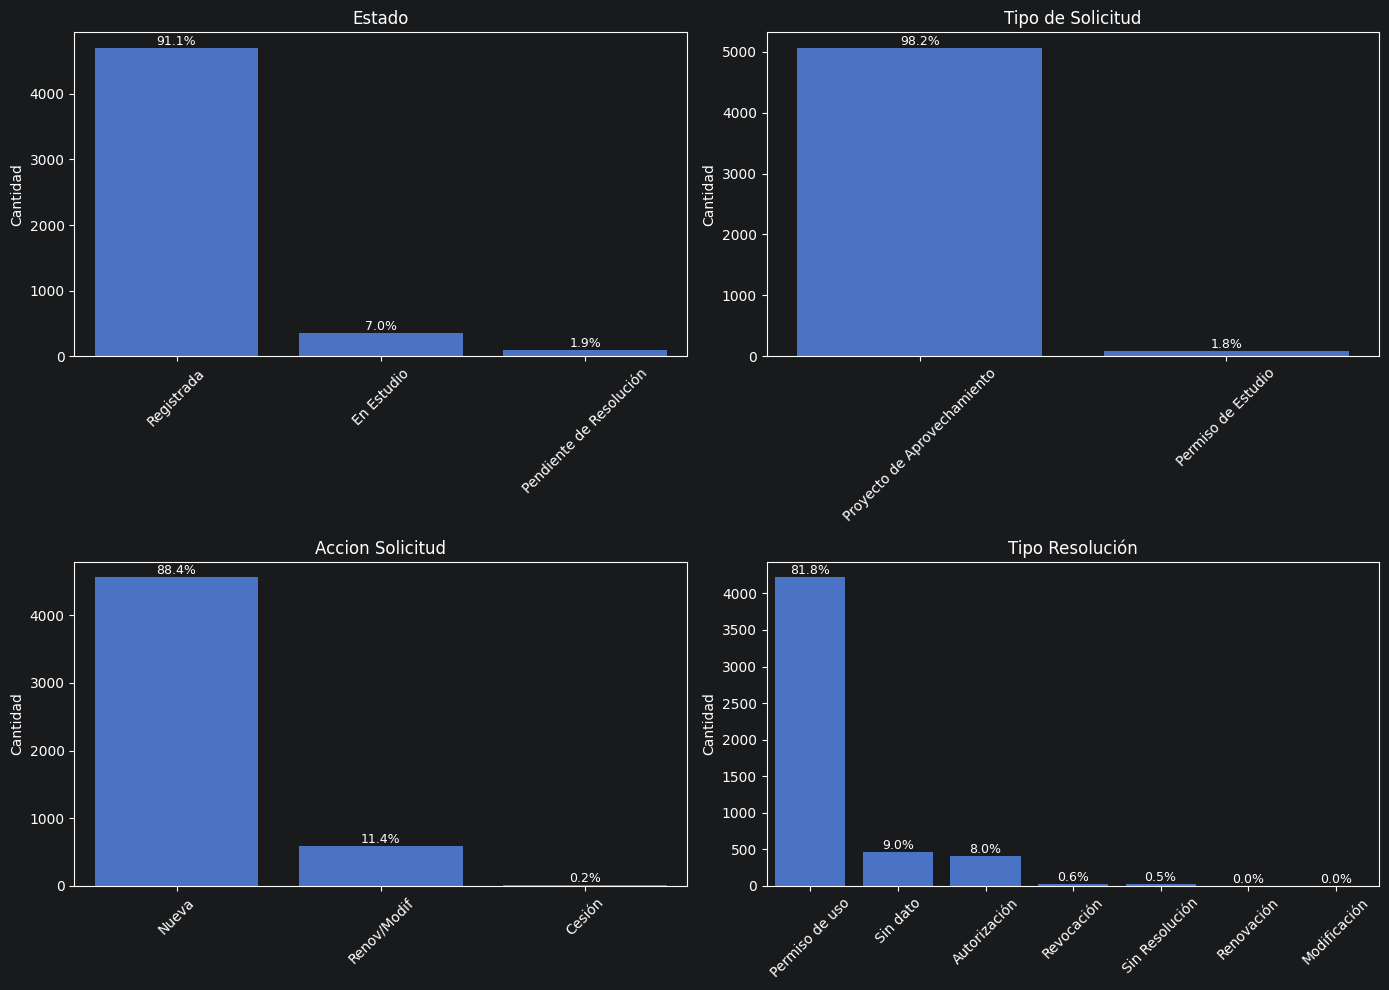

In [66]:
variables = [
    "Estado",
    "Tipo de Solicitud",
    "Accion Solicitud",
    "Tipo Resolución"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(variables):

    datos = df[col].fillna("Sin dato").astype(str)

    ax = sns.countplot(
        x=datos,
        order=datos.value_counts().index,
        ax=axes[i]
    )

    total = len(datos)

    for p in ax.patches:
        porcentaje = 100 * p.get_height() / total

        ax.annotate(
            f"{porcentaje:.1f}%",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Cantidad")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

De los anteriores gráficos de distribución de frecuencia se observa que:

En la variable Estado hay un marcado predominio de los expedientes Registrados (91,10% del total de los trámites analizados). Los expedientes En Estudio constituyen el 6,98%, y los Pendientes de Resolución representan únicamente el 1,92%. Esta distribución indica que la mayor parte de los trámites incluidos en la base de datos han completado su proceso administrativo.

Respecto al Tipo de Solicitud, los Proyectos de Aprovechamiento representan el 98,18% de los registros, mientras que los Permisos de Estudio alcanzan solamente el 1,82%. Esto evidencia que la gestión analizada se encuentra fuertemente orientada a solicitudes de aprovechamiento efectivo del recurso hídrico.

La variable Acción Solicitud muestra una predominancia de solicitudes Nuevas (88,41%), seguidas por las solicitudes de Renovación o Modificación (11,38%). Las solicitudes por Cesión tienen una participación marginal (0,21%), por lo que constituyen casos excepcionales dentro del conjunto de datos.

En cuanto a la variable Tipo Resolución, presenta como categoría predominante el Permiso de uso, que concentra el 81,82% de los registros. Las Autorizaciones representan el 8,02%, mientras que las categorías Revocación, Sin Resolución, Renovación y Modificación poseen una participación muy reducida. Asimismo, se observa un 9,03% de valores faltantes, los cuales corresponden principalmente a expedientes que aún se encuentran en estado En Estudio o Pendiente de Resolución, por lo que constituyen una situación esperable dentro del proceso administrativo y no un problema de calidad de los datos.

Se observa una marcada concentración de registros en determinadas categorías de las variables analizadas. En particular, los estados "Registrada", los "Proyectos de Aprovechamiento", las solicitudes "Nuevas" y las resoluciones de tipo "Permiso de uso" representan la gran mayoría de los registros. Esta distribución evidencia un comportamiento fuertemente asimétrico de estas variables categóricas, reflejando las características propias de los trámites analizados (mayoritariamente proyectos de aprovechamiento asociados a nuevas solicitudes que culminan con la obtención de un permiso de uso).


Luego de analizadas las variables asociadas al estado administrativo de los trámites, se procede a estudiar las variables Uso y Destino, las cuales permiten caracterizar la finalidad para la que se solicita el aprovechamiento del recurso hídrico.

La variable Uso representa una clasificación general del tipo de aprovechamiento, mientras que la variable Destino proporciona un mayor nivel de detalle sobre la actividad específica a desarrollar. El análisis conjunto de ambas variables permite identificar los principales sectores de demanda de agua y comprender la distribución de los trámites según su finalidad.

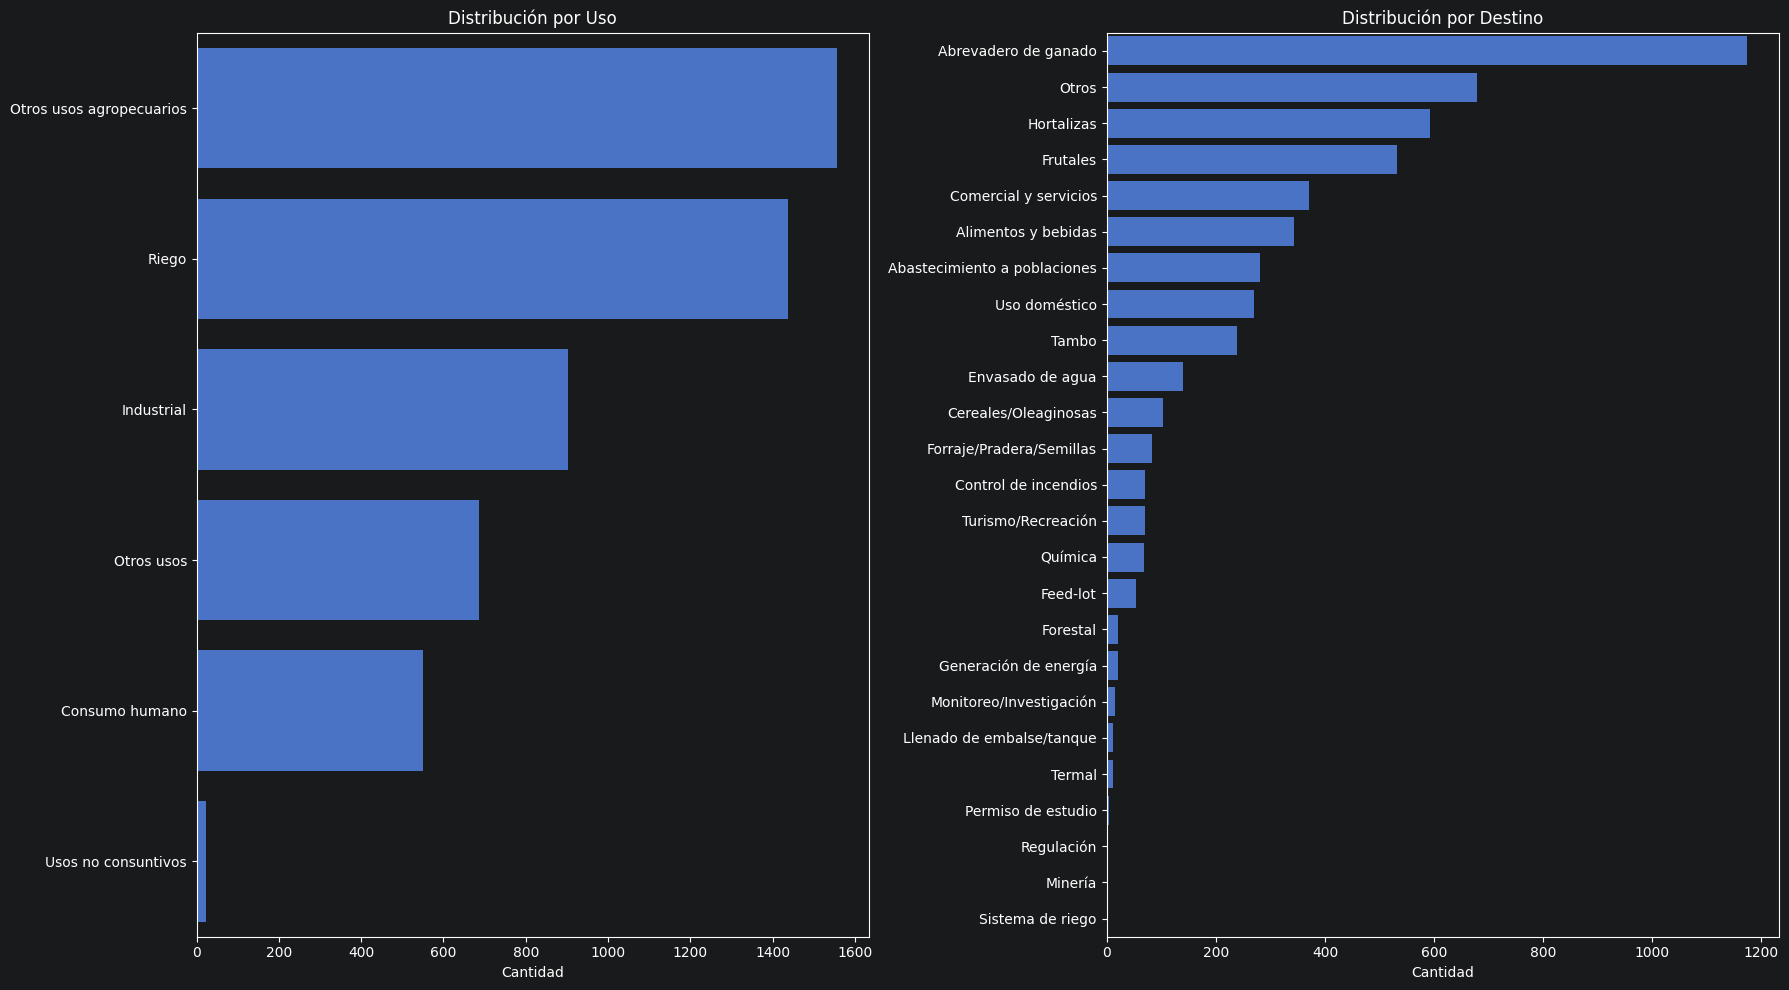

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Uso
sns.countplot(
    data=df,
    y="Uso",
    order=df["Uso"].value_counts().index,
    ax=axes[0]
)

axes[0].set_title("Distribución por Uso")
axes[0].set_xlabel("Cantidad")
axes[0].set_ylabel("")

# Destino
sns.countplot(
    data=df,
    y="Destino",
    order=df["Destino"].value_counts().index,
    ax=axes[1]
)

axes[1].set_title("Distribución por Destino")
axes[1].set_xlabel("Cantidad")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [83]:
tabla_uso = pd.DataFrame({
    "Cantidad": df["Uso"].value_counts(),
    "Porcentaje": round(df["Uso"].value_counts(normalize=True)*100, 2)
})

tabla_destino = pd.DataFrame({
    "Cantidad": df["Destino"].value_counts(),
    "Porcentaje": round(df["Destino"].value_counts(normalize=True)*100, 2)
})

print(tabla_uso.to_string())
print(tabla_destino.to_string())

                          Cantidad  Porcentaje
Uso                                           
Otros usos agropecuarios      1557       30.18
Riego                         1437       27.85
Industrial                     903       17.50
Otros usos                     687       13.32
Consumo humano                 551       10.68
Usos no consuntivos             24        0.47
                              Cantidad  Porcentaje
Destino                                           
Abrevadero de ganado              1174       22.76
Otros                              679       13.16
Hortalizas                         593       11.49
Frutales                           532       10.31
Comercial y servicios              370        7.17
Alimentos y bebidas                344        6.67
Abastecimiento a poblaciones       281        5.45
Uso doméstico                      270        5.23
Tambo                              238        4.61
Envasado de agua                   140        2.71
Cereales/Ole

De los gráficos y tablas anteriores se observa que:

En relación con la variable Uso, se observa que los trámites se concentran principalmente en las categorías Otros usos agropecuarios (30,18%) y Riego (27,85%), que en conjunto representan más de la mitad de los registros analizados. En segundo término se encuentran los usos Industriales (17,50%) y Otros usos (13,32%), mientras que el Consumo humano representa el 10,68% de los trámites. Los Usos no consuntivos poseen una participación marginal, alcanzando únicamente el 0,47% del total.

El análisis de la variable Destino permite observar con mayor detalle la finalidad específica de los aprovechamientos solicitados. La categoría más frecuente corresponde a Abrevadero de ganado (22,76%), seguida por Otros (13,16%), Hortalizas (11,49%) y Frutales (10,31%). También presentan una participación relevante los destinos vinculados a Comercial y servicios (7,17%), Alimentos y bebidas (6,67%), Abastecimiento a poblaciones (5,45%), Uso doméstico (5,23%) y Tambo (4,61%).

Los resultados evidencian un predominio de trámites asociados a actividades agropecuarias, particularmente aquellas vinculadas al riego, la producción hortifrutícola y el abastecimiento de agua para ganado. Asimismo, se observa una participación significativa de actividades industriales, comerciales y de abastecimiento humano, reflejando la diversidad de usos y destinos del recurso hídrico gestionados por el organismo.